## MNIST handwritten digits (28×28 grayscale images, 0–9).

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize (scale pixel values 0–1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Add channel dimension (needed for CNN: [batch, height, width, channels])
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


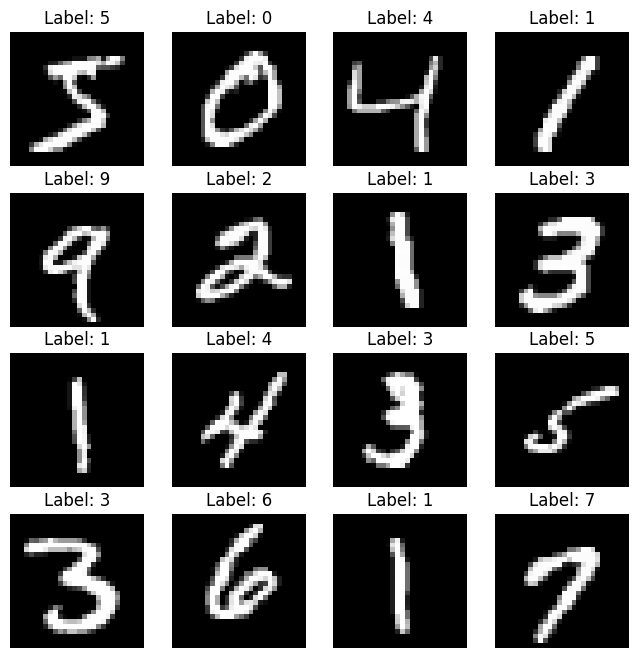

In [9]:
import matplotlib.pyplot as plt

# Show first 16 images from training set
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)   # 4x4 grid
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()


In [13]:
model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes (digits 0–9)
])

In [14]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
history = model.fit(x_train, y_train, epochs=5, 
                    validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9592 - loss: 0.1370 - val_accuracy: 0.9831 - val_loss: 0.0540
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9855 - loss: 0.0461 - val_accuracy: 0.9879 - val_loss: 0.0346
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9893 - loss: 0.0327 - val_accuracy: 0.9894 - val_loss: 0.0321
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9900 - val_loss: 0.0320
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9940 - loss: 0.0184 - val_accuracy: 0.9908 - val_loss: 0.0299


In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

313/313 - 1s - 2ms/step - accuracy: 0.9908 - loss: 0.0299
Test accuracy: 0.99
